# Bonus - the pop-out experiment, in code

In Week 1 I counted the 3s in a grid of digits twice: once plain and once with the 3s coloured. The coloured round was much faster, and that gap is preattentive processing. This week I build the experiment myself, run it on **five classmates**, and chart what happened.

The four panels:

1. **No channel** - every digit looks the same, so you have to read every cell.
2. **Colour** - the 3s are orange.
3. **Size only** - the 3s are bigger and bold, no colour.
4. **Colour and shape together** - orange *and* circled (redundant coding).

**How to run it (about 5 minutes per person):** set `RUN_EXPERIMENT = True` in the experiment cell below, type the participant's first name, and press Enter through the prompts. Each person is one run. After five people, set it back to `False` and re-run the notebook from the top so the chart and the write-up update.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Works both as a notebook (opened from week3/) and as a script (week3/submission/x.py)
try:
    ROOT = Path(__file__).resolve().parents[1]
    IN_NOTEBOOK = False
except NameError:
    ROOT = Path.cwd()
    IN_NOTEBOOK = True
sys.path.insert(0, str(ROOT))

import vizlib
from vizlib import PALETTE, MARKERS, save_fig, style_defaults

DATA = ROOT / "data"
CHARTS = ROOT / "charts"
SUB = ROOT / "submission"
CHARTS.mkdir(exist_ok=True)
SUB.mkdir(exist_ok=True)

style_defaults()                      # house rcParams, set once
BLUE, ORANGE, GREEN = PALETTE["series"]
PINK = PALETTE["series_4th"]
GREY = PALETTE["muted"]
INK = PALETTE["ink"]
INK_SOFT = PALETTE["ink_soft"]
SRC = "Synthetic data generated for CDB601220 (Week 3)."
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
warnings.filterwarnings("ignore", category=FutureWarning)


def finish(fig, name, note, folder=None):
    """Save FIRST (300 dpi, source note), then show. Never the other way round."""
    path = save_fig(fig, (folder or CHARTS) / f"{name}.png", note)
    if IN_NOTEBOOK:
        plt.show()
    plt.close(fig)
    print("saved ->", Path(path).relative_to(ROOT))
    return path


In [2]:
import time
from datetime import datetime

ROWS, COLS = 12, 18
TARGET = "3"
N_TARGETS = 9
SEED = 1947
PANELS = {1: "No channel", 2: "Colour", 3: "Size only", 4: "Colour + shape"}
RESULTS = ROOT / "bonus_results.csv"


def make_grid(seed=SEED):
    """A grid of digits with exactly N_TARGETS threes."""
    rng = np.random.default_rng(seed)
    others = [d for d in "0123456789" if d != TARGET]
    grid = np.array([[rng.choice(others) for _ in range(COLS)] for _ in range(ROWS)], dtype=object)
    for k in rng.choice(ROWS * COLS, size=N_TARGETS, replace=False):
        grid[k // COLS, k % COLS] = TARGET
    return grid


def draw(ax, grid, title, colour=False, size=False, shape=False):
    ax.set_xlim(-0.5, COLS - 0.5)
    ax.set_ylim(-0.5, ROWS - 0.5)
    ax.invert_yaxis()
    ax.axis("off")
    ax.set_title(title, fontsize=10.5, loc="left")
    for r in range(ROWS):
        for c in range(COLS):
            d = grid[r, c]
            hit = d == TARGET
            if shape and hit:
                ax.add_patch(plt.Circle((c, r), 0.42, fill=False, edgecolor=INK, lw=1.6))
            ax.text(c, r, d, ha="center", va="center",
                    fontsize=16 if (size and hit) else 11,
                    fontweight="bold" if (size and hit) else "normal",
                    color=PALETTE["highlight"] if (colour and hit) else INK)


STYLE = {1: {}, 2: {"colour": True}, 3: {"size": True}, 4: {"colour": True, "shape": True}}

## The four panels (same grid, same 9 targets, same positions)

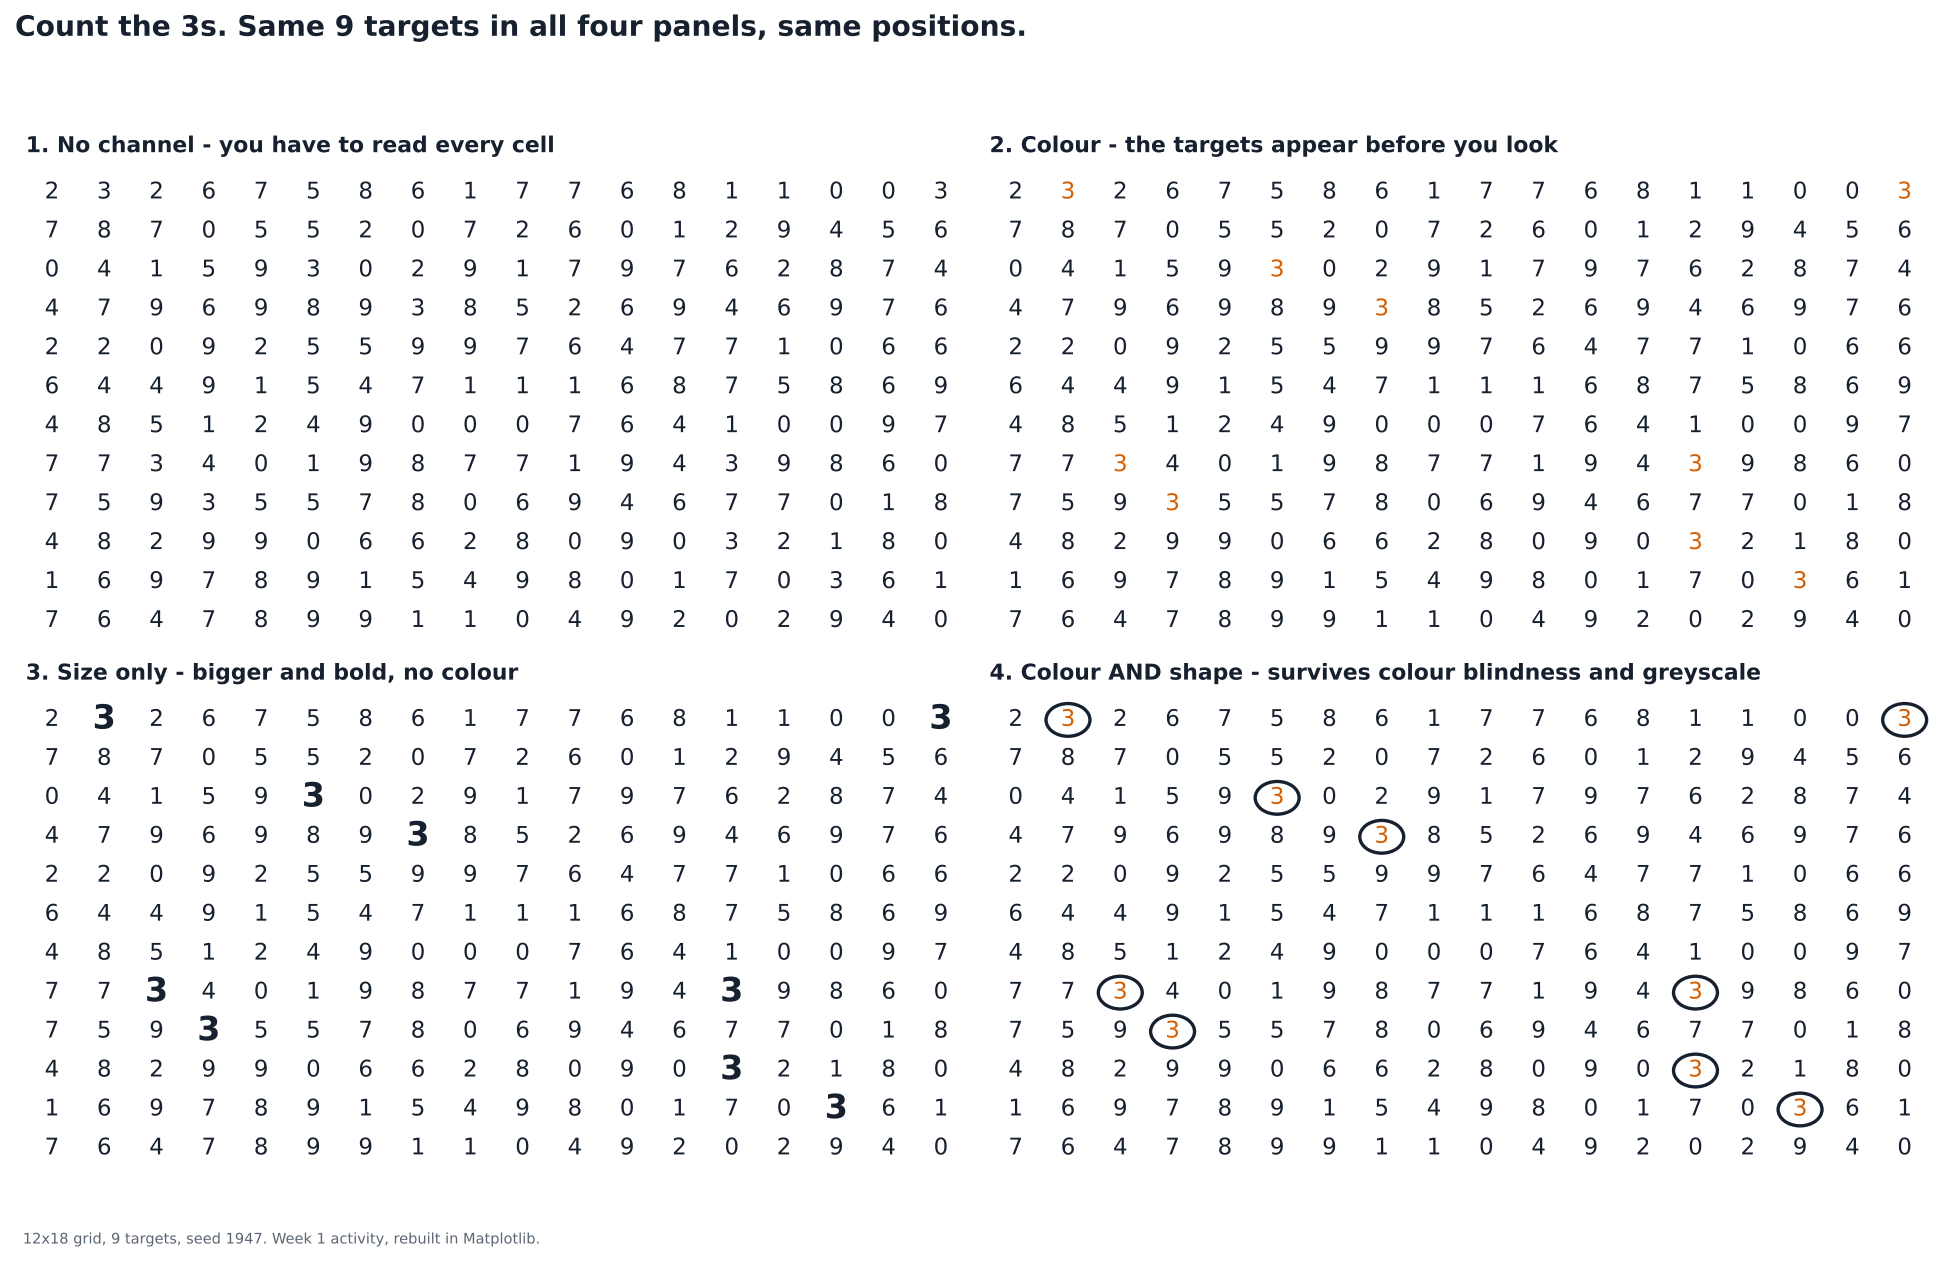

saved -> submission/popout_panels.png


'/home/claude/week3/submission/popout_panels.png'

In [3]:
grid = make_grid()
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
titles = {1: "1. No channel - you have to read every cell",
          2: "2. Colour - the targets appear before you look",
          3: "3. Size only - bigger and bold, no colour",
          4: "4. Colour AND shape - survives colour blindness and greyscale"}
for p, a in zip(PANELS, ax.flat):
    draw(a, grid, titles[p], **STYLE[p])
fig.suptitle(f"Count the {TARGET}s. Same {N_TARGETS} targets in all four panels, same positions.",
             x=0.006, ha="left", fontsize=13.5, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
finish(fig, "popout_panels", f"{ROWS}x{COLS} grid, {N_TARGETS} targets, seed {SEED}. Week 1 activity, rebuilt in Matplotlib.", folder=SUB)

**What this chart shows.** All four panels have the same 9 threes in the same places; only the way they're highlighted changes. In panel 1 you have to read every digit. In panels 2 and 4 the colour makes the 3s jump out almost straight away, and the circles in panel 4 still work if you can't see colour.

## The timing harness

Two design decisions, both to make the comparison fair:

- **A fresh grid for every panel in the experiment.** If a person sees the same grid four times, by the fourth time they remember where the 3s are, and the last panel looks fast because of memory, not because of the channel. So in the experiment each panel uses its own grid (seeds 1001-1004), every grid has exactly 9 threes, and only the encoding changes. The figure above uses one shared grid because that is what the brief asks the panels to show.
- **A different random order for every person.** The order comes from `numpy.random.default_rng(<participant number>)` and is written into the CSV, so practice and fatigue are spread across all four panels instead of always hitting the same one.

Timing: the clock starts when the panel is drawn and stops when the person presses Enter, then they type how many 3s they counted. I record the time, their answer, and whether it was 9.

In [4]:
EXP_SEEDS = {1: 1001, 2: 1002, 3: 1003, 4: 1004}


def _show_panel(p):
    g = make_grid(EXP_SEEDS[p])
    fig, ax = plt.subplots(figsize=(10, 6.6))
    draw(ax, g, "", **STYLE[p])
    fig.tight_layout()
    if IN_NOTEBOOK:
        from IPython.display import display
        display(fig)
    else:
        plt.show(block=False)
        plt.pause(0.3)
    return fig


def _hide(fig):
    plt.close(fig)
    if IN_NOTEBOOK:
        from IPython.display import clear_output
        clear_output(wait=True)


def run_participant(name):
    old = pd.read_csv(RESULTS) if RESULTS.exists() else pd.DataFrame()
    pid = 1 if old.empty else int(old.participant_no.max()) + 1
    order = [int(x) for x in np.random.default_rng(pid).permutation(list(PANELS))]
    print(f"Participant {pid} ({name}). Panel order: {order}")
    input("Say to them: 'Count the 3s as fast as you can, press Enter the moment you are done.' Press Enter to start... ")
    rows = []
    for pos, p in enumerate(order, start=1):
        input(f"Trial {pos} of 4 - press Enter when they are ready... ")
        fig = _show_panel(int(p))
        t0 = time.perf_counter()
        input("Press Enter the MOMENT they finish counting: ")
        secs = time.perf_counter() - t0
        _hide(fig)
        ans = input("How many 3s did they count? ").strip()
        rows.append({"participant_no": pid, "participant": name, "panel": int(p), "panel_name": PANELS[int(p)],
                     "order_position": pos, "seconds": round(secs, 2), "answer": ans,
                     "correct": ans == str(N_TARGETS), "timestamp": datetime.now().isoformat(timespec="seconds")})
        print(f"  panel {p}: {secs:.2f} s, answer {ans}")
    new = pd.concat([old, pd.DataFrame(rows)], ignore_index=True)
    new.to_csv(RESULTS, index=False)
    print(f"saved -> {RESULTS.name} ({new.participant_no.nunique()} participant(s) so far)")
    return new

In [5]:
RUN_EXPERIMENT = False                       # set True, run this cell once per participant
PARTICIPANT = "first name of the participant"

if not IN_NOTEBOOK and "--run" in sys.argv:
    RUN_EXPERIMENT = True
    PARTICIPANT = input("Participant first name: ").strip() or "anonymous"

if RUN_EXPERIMENT:
    if PARTICIPANT.startswith("first name"):
        raise ValueError("Type the participant's first name into PARTICIPANT first.")
    run_participant(PARTICIPANT)

if RESULTS.exists():
    res = pd.read_csv(RESULTS)
    print(res.to_string(index=False))
else:
    res = None
    print("No bonus_results.csv yet - run the experiment on your five classmates first (RUN_EXPERIMENT = True).")

No bonus_results.csv yet - run the experiment on your five classmates first (RUN_EXPERIMENT = True).


## The result chart

Mean seconds per panel as a faded bar, with every individual time on top as a strip plot. With only five people, showing the raw points is better than any summary: you can see straight away if one slow person is pulling a mean up. The y-axis starts at zero because a bar is a length.

In [6]:
def results_chart(res):
    n = res.participant_no.nunique()
    ok = res[res.correct]
    wrong = res[~res.correct]
    means = res.groupby("panel").seconds.mean().reindex(list(PANELS))
    fastest, slowest = means.idxmin(), means.idxmax()
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    bar_cols = [ORANGE if p == fastest else GREY for p in PANELS]
    ax.bar(range(4), means.values, color=bar_cols, alpha=0.35, width=0.6, zorder=1)
    rng = np.random.default_rng(0)
    for p in PANELS:
        g = ok[ok.panel == p]
        ax.scatter(p - 1 + rng.uniform(-0.12, 0.12, len(g)), g.seconds, color=BLUE, s=34, zorder=3)
        gw = wrong[wrong.panel == p]
        ax.scatter(p - 1 + rng.uniform(-0.12, 0.12, len(gw)), gw.seconds, facecolors="none", edgecolors=ORANGE,
                   s=40, marker="o", lw=1.4, zorder=3, label="wrong count" if p == 1 and len(gw) else None)
        ax.text(p - 1, means[p] + res.seconds.max() * 0.03, f"{means[p]:.1f} s", ha="center", fontsize=9.5, fontweight="bold")
    ax.set_xticks(range(4))
    ax.set_xticklabels([f"{p}. {PANELS[p]}" for p in PANELS])
    ax.set_ylim(0, res.seconds.max() * 1.18)
    ax.set_ylabel("Seconds to count the 3s")
    if len(wrong):
        ax.legend(loc="upper right")
    ratio = means[slowest] / means[fastest]
    ax.set_title(f"{PANELS[fastest]} was fastest: {means[fastest]:.1f} s vs {means[slowest]:.1f} s for "
                 f"{PANELS[slowest].lower()} ({ratio:.1f}x)")
    note = (f"n = {n} participants, 4 trials each. Order randomised per person with numpy default_rng(participant number); "
            f"a fresh 12x18 grid with 9 targets per panel (seeds 1001-1004). Bars = mean, dots = individual times; "
            f"hollow = wrong count ({len(wrong)}).")
    finish(fig, "popout_results", note, folder=SUB)
    return means


if res is not None:
    means = results_chart(res)
    print(means.round(2))
    print("participants so far:", res.participant_no.nunique(), "(the brief asks for 5)")

**What this chart shows.** Each dot is one person's time and the bar is the average. With only five people, showing every dot lets you see whether one slow person is pulling the average up. The three sentences below the chart are written from this data, so read the chart and those together.

## Three sentences on the result

In [7]:
if res is not None:
    m = res.groupby("panel").seconds.mean()
    f, s = m.idxmin(), m.idxmax()
    diff = m[4] - m[2]
    why = {2: "because colour is preattentive: the orange 3s were picked out in parallel, without reading the grid",
           4: "because colour (helped by the circles) is preattentive: the 3s were picked out in parallel, without reading the grid",
           3: "so size worked as a pop-out channel for this group, even without colour",
           1: "which goes against the textbook; I checked the individual times and the order each person saw the panels in"}
    print(f"1. The fastest panel was {PANELS[f].lower()} ({m[f]:.1f} s on average), {why[f]}.")
    print(f"2. The slowest was {PANELS[s].lower()} ({m[s]:.1f} s), "
          + ("which is what we expect: with no channel every cell has to be read one by one."
             if s == 1 else "which is not what the textbook predicts, so I looked at the individual times to see if one person caused it."))
    print(f"3. Adding shape on top of colour changed the mean by {diff:+.1f} s compared with colour alone, "
          + ("so redundant coding cost almost nothing in speed while making the chart readable for colour-blind people."
             if abs(diff) < 0.25 * m[2] else
             "which is a bigger difference than expected; with only five people one slow trial can do this, so I would not read too much into it."))
else:
    print("Waiting for the five runs. The sentences are generated from your own data once bonus_results.csv exists.")

Waiting for the five runs. The sentences are generated from your own data once bonus_results.csv exists.


*After the five runs, read the three generated sentences and rewrite them in your own words in this cell, adding anything you noticed while watching people (for example, someone who counted 8 because they skipped a row, or someone who said the circles helped). Results that disagree with the textbook still score full marks when they are reported honestly.*